In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from rw import gw_handler

from matplotlib import rc
from matplotlib  import cm
from matplotlib import gridspec

from rw import scan_handler
from process import utils as ut
from matplotlib import gridspec

from iminuit import cost,Minuit, describe
import iminuit

rc('text', usetex=False)
rc('font', family='serif', size=15)
rc('figure', figsize=(8,6))
rc('axes',linewidth=2)
rc("xtick.major", size=10, width=1.5)
rc("ytick.major", size=10, width=1.5)
rc("xtick", labelsize=15)
rc("ytick", labelsize=15)
rc("xtick.minor", size=10, width=1.2)
rc("ytick.minor", size=10, width=1.2)

In [5]:
def set_defaults():
    rc('text', usetex=False)
    rc('font', family='serif', size=20)
    rc('figure', figsize=(12,8))
    rc('axes',linewidth=2)
    return

# Open scan file

In [6]:
file_path = "/home/matteo/Scrivania/lavoracci/Bauscia/Data/RK41_2.scan"    # path to the .scan file

reader = scan_handler.ScanReader(file_path)   

In [7]:
# print the temperatures (K) in the .scan
print(reader.get_temperatures())

['4']


In [8]:
# set the temperature
reader.set_temperature('4')

In [9]:
# each resonance has some parameters associated. 
# Print the parameters present in the dataset
reader.get_parameters_tags()

['C',
 'C0',
 'L',
 'Q0_bvd',
 'Q0_c',
 'Ql_c',
 'R',
 'b1',
 'b2',
 'bw',
 'fcenter',
 'fmax',
 'fmin',
 'input_power',
 'npt',
 'span',
 'sweep']

| Name | Meaning | Note |
| --- | --- | --- |
| C,C0,L,R | Parameters of the RLC + C0 model (F,H,Ohm) | Default fit option are used |
| Q0_bvd | Unloaded Q evaluated with the BVD model. S21 data only | Default fit option are used |
| Q0_c | Unloaded Q evaluated using S21, S22 and S11 data. (circle fit)  | Default fit option are used |
| Q0_l | Loaded Q evaluated using S21, S22 and S11 data. (circle fit)  | Default fit option are used |
| b1 | reflection coefficient for the port 1  | Default fit option are used |
| b2 | reflection coefficient for the port 2  | Default fit option are used |
| bw | VNA ifbw  |  |
| fcenter | VNA center frequency (Hz) |  |
| fmax | VNA maximum frequency (Hz) |  |
| fmin | VNA minimum frequency (Hz) |  |
| input_power | VNA input power (dBm) |  |
| npt | VNA number of points  |  |
| span | VNA span  |  |
| sweep | VNA sweep time (s) |  |

In [18]:
# Return the selected parameter for each recorded resonance.
# If the parameter is not present for a resonance, the default value is used instead
# the array index is the same as the loc option in the .get_resonance method
# i.e. Qc[3] correspond to the "Q0_c" value of the resonance reader.get_resonance(loc=3) 
Qc = reader.get_parameters("Q0_c", default=-2)

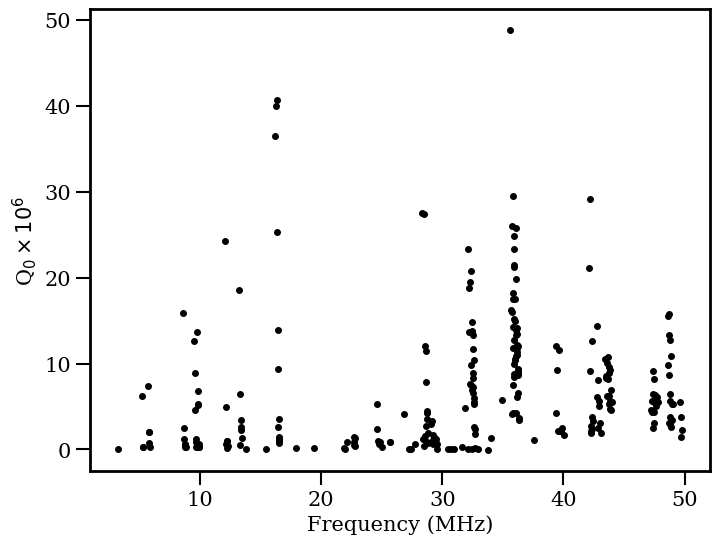

In [27]:
# Plot Q0 vs f of the recorded resonances
# Plot only the resonance where Q0_c and Q0_bvd are similar (it should reduce noise data)

Qc = reader.get_parameters("Q0_c")
Qb = reader.get_parameters("Q0_bvd")
Ql = reader.get_parameters("Ql_c")

f0 = reader.get_parameters("fcenter")

ii = np.where(np.abs(Qc-Qb)<1e7)[0]

plt.plot(f0[ii]*1e-6,Qc[ii]*1e-6,"o",ms=4,c='k')
plt.xlabel("Frequency (MHz)")
plt.ylabel(r"Q$_0 \times 10^6$")
plt.show()

In [28]:
# get (as a python dictionary) all the resonance parameter. 
# you can get a resonance from its raw name
#           reader.get_resonance(name="resonance_10")
# you can get a resonance from its position inside the .scan
# e.g.: get the seventh resonance
#           reader.get_resonance(loc=7)
# you can get the resonance from its frequency (the middle frequency). 
# it gets the closest resonance to the selected frequency

freq = 5.175e6 #Hz
label = "S21"
#=====================================

reso = reader.get_resonance(freq=freq,label="S21")
#reso = reader.get_resonance(loc=0,label="S21")

reso

{'C': 2.2309473334283046e-16,
 'C0': 2.496335108536927e-12,
 'L': 4.25116539584997,
 'Q0_bvd': 7177352.814537481,
 'Q0_c': 6228674.255478187,
 'Ql_c': 1176547.9089483907,
 'Qr': 678790.3242561771,
 'R': 19.232912102651177,
 'b1': 2.2883611220687725,
 'b2': 2.005664057955926,
 'bw': 10.0,
 'depth': 0.8425555030668865,
 'f0': 5167987.7092386745,
 'fcenter': 5168006.0,
 'fmax': 5168106.0,
 'fmin': 5167906.0,
 'input_power': -18.0,
 'npt': 1601.0,
 'span': 200.0,
 'sweep': 166.608056090624,
 'freq': array([5167906.   , 5167906.125, 5167906.25 , ..., 5168105.75 ,
        5168105.875, 5168106.   ]),
 'phase': array([ 1.57079633,  1.53609711,  1.54299941, ..., -1.55340488,
        -1.55300037, -1.55262955]),
 'power': array([-30.51260058, -30.56398948, -30.59521948, ..., -41.01583617,
        -41.02880759, -41.04859183]),
 'reso_name': 'resonance_3'}

# See single resonance data

In [48]:
nn =  222              #resonance location or None 
freq = None            #resonance frequency (Hz) or None
skip = 10              #points to skip

if freq is not None:
    reso = reader.get_resonance(freq=freq,label="S21")
    nn = np.where(reader.get_parameters("Q0_bvd")==reso["Q0_bvd"])[0][0]
print("Resonance loc: ", nn)

Resonance loc:  222


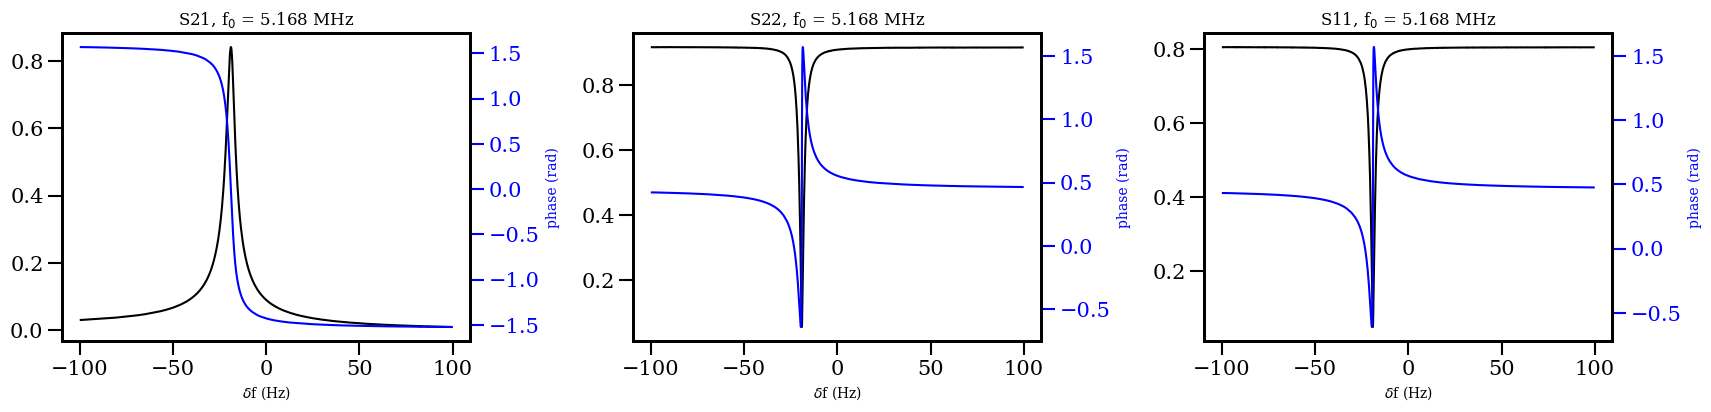

In [49]:
# Plot recorded data for the chosen resonance
###########################

rc('text', usetex=False)
rc('font', family='serif', size=10)
rc('figure', figsize=(20,4))
rc('axes',linewidth=2)

gs = gridspec.GridSpec(1, 3)
gs.update(wspace = 0.4, hspace=0.4)
ax = plt.subplot(gs[0, 0])
reso = reader.get_resonance(loc=nn,label="S21")
S = 10**(reso["power"]/20)[skip:]
freq = reso['freq'][skip:]
phase = reso["phase"][skip:]
phase = np.unwrap(phase)
phase = phase-np.max(phase)+np.pi/2
f0 = freq[len(freq)//2]
label =r"f$_0$ = "+ str(np.round(f0*1e-6,3))+ " MHz"
ax.plot(freq-f0,S,c='k')
ax.set_xlabel(r"$\delta$f (Hz)")
ax2 = ax.twinx()
ax2.plot(freq-f0,phase,color="b")
ax2.set_ylabel('phase (rad)', color='b')
ax2.tick_params(axis='y', colors='b')
ax.set_title(r"S21, "+label)

ax = plt.subplot(gs[0, 1])
ax.set_title(r"S22, "+label)
reso = reader.get_resonance(loc=nn,label="S22")
S = 10**(reso["power"]/20)[skip:]
freq = reso['freq'][skip:]
phase = reso["phase"][skip:]
phase = np.unwrap(phase)
phase = phase-np.max(phase)+np.pi/2
f0 = freq[len(freq)//2]
ax.plot(freq-f0,S,c='k')
ax2 = ax.twinx()
ax2.plot(freq-f0,phase,color="b")
ax2.set_ylabel('phase (rad)', color='b')
ax2.tick_params(axis='y', colors='b')
ax.set_xlabel(r"$\delta$f (Hz)")

ax = plt.subplot(gs[0, 2])
ax.set_title(r"S11, "+label)
reso = reader.get_resonance(loc=nn,label="S11")
S = 10**(reso["power"]/20)[skip:]
freq = reso['freq'][skip:]
phase = reso["phase"][skip:]
phase = np.unwrap(phase)
phase = phase-np.max(phase)+np.pi/2
f0 = freq[len(freq)//2]
ax.plot(freq-f0,S,c='k')
ax2 = ax.twinx()
ax2.plot(freq-f0,phase,color="b")
ax2.set_ylabel('phase (rad)', color='b')
ax2.tick_params(axis='y', colors='b')
ax.set_xlabel(r"$\delta$f (Hz)")

plt.show()
set_defaults()

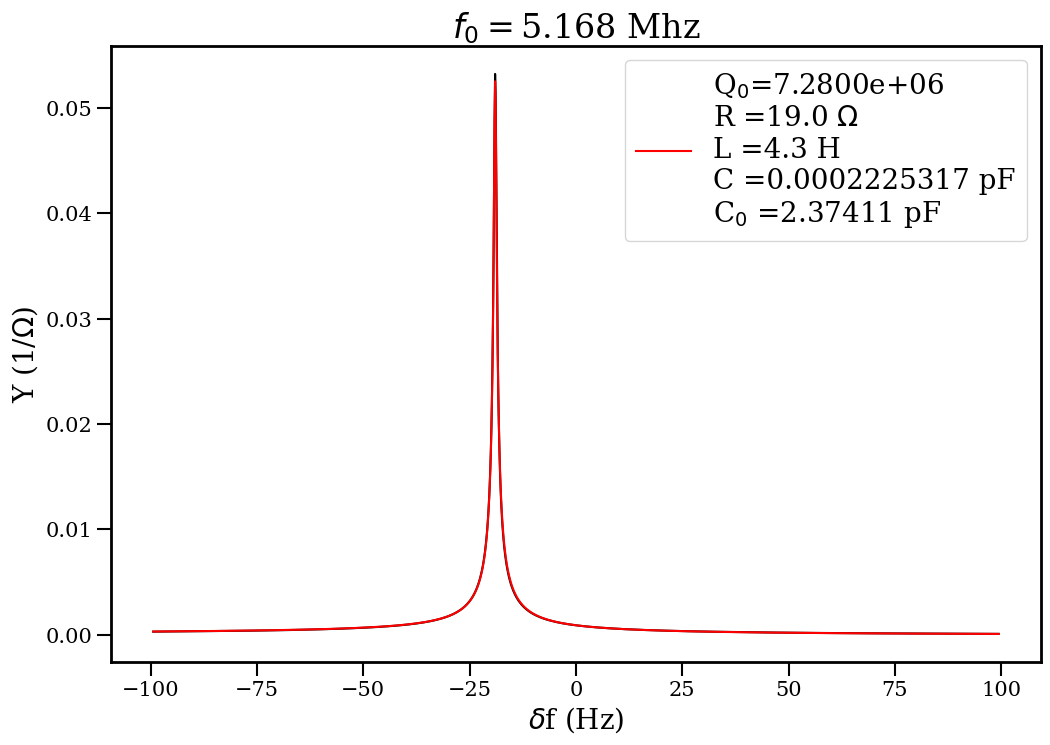

In [50]:
# Plot BVD model fit with default parameters
###########################

nreso = reader.get_resonance(loc=nn,label="S21")
skip = 10
freq =nreso["freq"]
power =(10**(nreso["power"]/20))

S = power[skip:]
phase = nreso["phase"][skip:]
freq = freq[skip:]

real = np.sqrt((S**2)/(1+np.tan(phase)**2))  
imag = np.tan(phase)*real
    
Z = 2*50*(real/(S**2)-1j*imag/(S**2) -1)      #impedance
Y = 1./Z  


fc0 = freq[np.argmax(np.real(Y))]

m1,R,L,C,C0, Q0 =ut.fit_resonance_bvd(nreso["freq"],nreso["power"],nreso["phase"],skip=skip)

f0 = freq[len(freq)//2]
plt.plot(freq-f0, np.abs(Y),c="k")
fc = 1/(2*np.pi)*(1./(L*C)**0.5)
label = "Q$_0$="+f"{Q0:.4e}" +"\n"
label +="R ="+str(np.round(R,1)) + " $\Omega$" +"\n"
label +="L ="+str(np.round(L,1)) + " H" +"\n"
label +="C ="+str(np.round(C*1e12,10)) + " pF" +"\n"
label +="C$_0$ ="+str(np.round(C0*1e12,5)) + " pF"

plt.plot(freq-f0,ut.fit_minuit_bvd(freq,L,fc,Y),c="r",label=label)
plt.legend()
plt.title(r"$f_0=$"+str(np.round(f0*1e-6,3))+ " Mhz")
plt.xlabel(r"$\delta$f (Hz)")
plt.ylabel("Y (1/$\Omega$)")
plt.show()

/home/matteo/bawenv/lib/python3.8/site-packages/process/utils.py:264: VisibleDeprecationWarning: make_func_code is deprecated: Use of `func_code` attribute to declare parameters is deprecated. Use `_parameters` instead, which is a dict of parameter names to limits.
  self.func_code = iminuit.util.make_func_code(describe(self.fc)[1:])
/home/matteo/bawenv/lib/python3.8/site-packages/iminuit/util.py:1297: VisibleDeprecationWarning: Using the `func_code` attribute to dynamically declare parameter names is deprecated, use the attribute `_parameters` instead (a dict of strings to limits)
  warnings.warn(


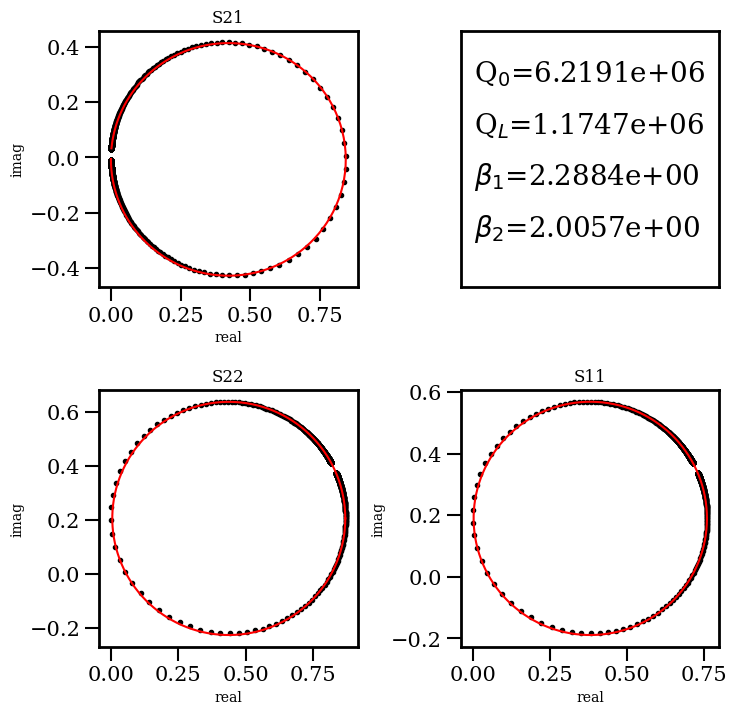

In [51]:
# Plot "circle" model fit with default parameters
###########################

m1, Ql, Q0, beta1, beta2 =ut.fit_resonance_circle(reader.get_resonance(loc=nn,label="S21"),reader.get_resonance(loc=nn,label="S22"),reader.get_resonance(loc=nn,label="S11"))

rc('text', usetex=False)
rc('font', family='serif', size=10)
rc('figure', figsize=(8,8))
rc('axes',linewidth=2)

gs = gridspec.GridSpec(2, 2)
gs.update(wspace = 0.4, hspace=0.4)
  
ax = plt.subplot(gs[0, 0])
ax.set_title(r"S21")
reso = reader.get_resonance(loc=nn,label="S21")
S = 10**(reso["power"]/20)[skip:]
freq = reso['freq'][skip:]
phase = reso["phase"][skip:]

real = np.sqrt((S**2)/(1+np.tan(phase)**2))  # +/-
imag = np.tan(phase)*real
ax.plot(real,imag,".",c='k')

xfit = np.linspace(np.min(freq),np.max(freq),3000)

fitres = ut.fit_minuit_gregory(xfit,*np.array(m1.values))
ax.plot(np.real(fitres),np.imag(fitres),c="r")
ax.set_xlabel("real")
ax.set_ylabel("imag")

ax = plt.subplot(gs[0, 1])
ax.text(0.05,0.8,"Q$_0$="+f"{Q0:.4e}",fontsize=20)
ax.text(0.05,0.6,"Q$_L$="+f"{Ql:.4e}",fontsize=20)
ax.text(0.05,0.4,r"$\beta_1$="+f"{beta1:.4e}",fontsize=20)
ax.text(0.05,0.2,r"$\beta_2$="+f"{beta2:.4e}",fontsize=20)

ax.set_xticks([])
ax.set_yticks([])

for i in range(2):
    ax = plt.subplot(gs[1, i])
    label = "S"+str(2-i)*2
    ax.set_title(label)
    reso = reader.get_resonance(loc=nn,label=label)
    S = 10**(reso["power"]/20)[skip:]
    freq = reso['freq'][skip:]
    phase = reso["phase"][skip:]
    phase = np.unwrap(phase)
    phase = phase-np.max(phase)+ np.pi/2

    real = np.sqrt((S**2)/(1+np.tan(phase)**2))  # +/-
    imag = np.tan(phase)*real
    xc, yc,radius =ut.circlefit(real,imag,np.mean(real),np.mean(imag))
    ax.plot(real,imag,".",c='k')
    theta = np.linspace( 0 , 2 * np.pi , 400 )
    a = radius * np.cos( theta )
    b = radius * np.sin( theta )
    ax.plot( a+xc, b+yc,c='r',label="fit" )
    ax.set_xlabel("real")
    ax.set_ylabel("imag")

plt.show()
set_defaults()

# Exercise

In [1]:
# 1) plot the S21 for all the resonance with a Q value greater than 1e6 and frequency below 6e6 Hz